---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---


---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 1 : DATA EXPLORATION (Camille)

---


In [ ]:
# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
print("Imports OK")


In [ ]:
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")


In [ ]:
# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


In [ ]:
# Constantes et dataset
DATA_DIR = os.path.join(".", "data")
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES = 9

train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASS_NAMES = list(labels_names.values())

notebook_start_time = time.time()

print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")


---
## Part 1: Data Exploration
We load PathMNIST, examine its structure, visualise sample images, and characterise the class distribution and pixel statistics before building any model.


In [ ]:
# Loading dataset
info = INFO['pathmnist']
# give informations about the dataset
print("Dataset info:")
print(f"  Task: {info['task']}")
print(f"  N classes: {info['n_channels']} channels, {len(info['label'])} classes")
# channels : 3 (RGB)
# classes : 9 different tissue types
print(f"  Labels: {info['label']}")

CLASSES = list(info['label'].values())
print(f"\nClass names: {CLASSES}")
# get the tissue name into a list for later use

# Raw (no normalisation) for pixel statistics
raw_transform = transforms.Compose([transforms.ToTensor()])
# rescale values and convert to tensor
# no normalisation yet, we want to see the original pixel value distribution
# tensor : multi-dimensional array used in PyTorch for storing data and gradients
# change from PIL image (H×W×C, uint8 in [0,255]) to tensor (C×H×W, float32 in [0,1])

train_raw = PathMNIST(split='train', transform=raw_transform, download=True)
val_raw   = PathMNIST(split='val',   transform=raw_transform, download=True)
test_raw  = PathMNIST(split='test',  transform=raw_transform, download=True)
# download and load the dataset
# 3 different splits : train, validation, test

print(f"\nSplit sizes = train: {len(train_raw):,}, val: {len(val_raw):,}, test: {len(test_raw):,}")
print(f"Image shape = {train_raw[0][0].shape} ")


Dataset info:
  Task: multi-class
  N classes: 3 channels, 9 classes
  Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

Class names: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']

Split sizes = train: 89,996, val: 10,004, test: 7,180
Image shape = torch.Size([3, 28, 28]) 


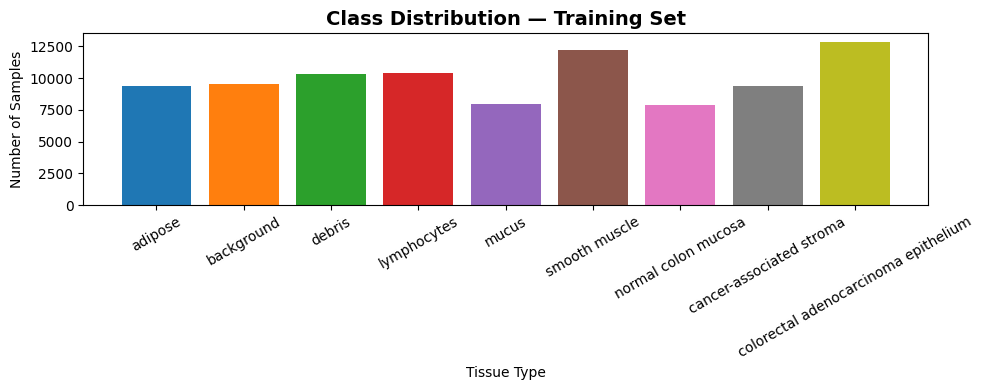


Counts per class:
   0  adipose                9,366
   1  background             9,509
   2  debris                10,360
   3  lymphocytes           10,401
   4  mucus                  8,006
   5  smooth muscle         12,182
   6  normal colon mucosa    7,886
   7  cancer-associated stroma   9,401
   8  colorectal adenocarcinoma epithelium  12,885


In [ ]:
# Class distribution
all_labels = np.array([int(train_raw[i][1]) for i in range(len(train_raw))])
# loop every image in the training and extract the label
# tuple (image, label) so 1 is the label
unique, counts = np.unique(all_labels, return_counts=True)
# count how many time each value appears

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar([CLASSES[u] for u in unique], counts, color=sns.color_palette("tab10", 9))
ax.set_title("Class Distribution — Training Set", fontsize=14, fontweight='bold')
ax.set_xlabel("Tissue Type")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print("\nCounts per class:")
for u, c in zip(unique, counts):
    print(f"  {u:2d}  {CLASSES[u]:<20s}  {c:6,}")


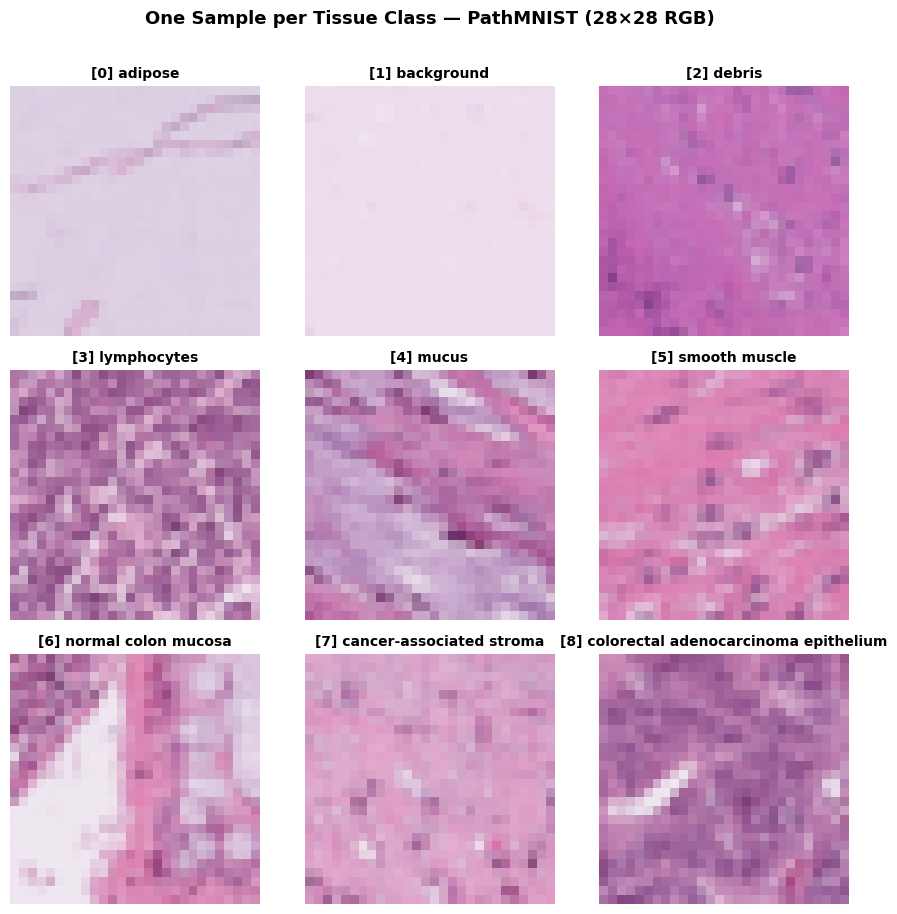

In [ ]:
# Data exploration: visualisation of the figures
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

# Collect one representative image per class
class_examples = {}
for img, label in train_raw:
    lbl = int(label)
    if lbl not in class_examples:
        class_examples[lbl] = img
    if len(class_examples) == 9:
        break
# Loop through the dataset
# Save the first image found for each class

for image_exploration in range(9):
    img = class_examples[image_exploration].permute(1, 2, 0).numpy()
    # PyTorch stores images as [C, H, W] but matplotlib expects [H, W, C]
    axes[image_exploration].imshow(img)
    axes[image_exploration].set_title(f"[{image_exploration}] {CLASSES[image_exploration]}", fontsize=10, fontweight='bold')
    axes[image_exploration].axis('off')
    # No x y axis and numbers

plt.suptitle("One Sample per Tissue Class — PathMNIST (28×28 RGB)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


You need to check the particularities of each image and what are the differences between the different categories

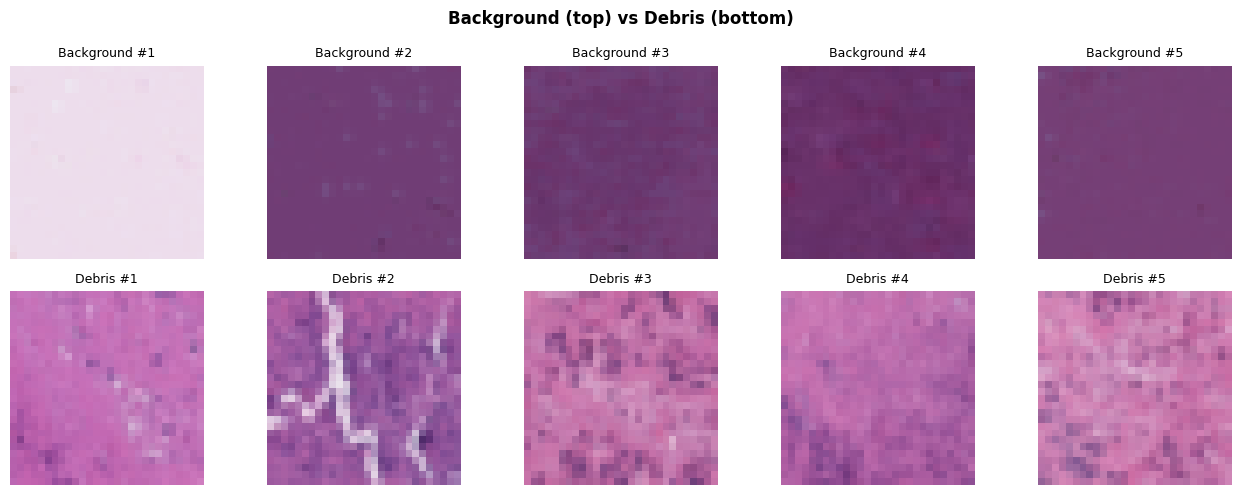

In [ ]:
# Data exploration: debris vs background
# Collect 5 examples each of Background (1) and Debris (2)
debris_imgs, bg_imgs = [], []
for img, label in train_raw:
    lbl = int(label)
    if lbl == 2 and len(debris_imgs) < 5:
        debris_imgs.append(img)
    if lbl == 1 and len(bg_imgs) < 5:
        bg_imgs.append(img)
    if len(debris_imgs) == 5 and len(bg_imgs) == 5:
        break

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i in range(5):
    axes[0, i].imshow(bg_imgs[i].permute(1,2,0).numpy())
    axes[0, i].set_title(f"Background #{i+1}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(debris_imgs[i].permute(1,2,0).numpy())
    axes[1, i].set_title(f"Debris #{i+1}", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Background (top) vs Debris (bottom)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Q1.1 Debris vs Background

**Background** images are characterised by a nearly uniform, very light pinkish-white (almost white) field with no visible cellular structure.  The texture is essentially flat, a natural consequence of empty slide areas that contain no tissue

**Debris** images, by contrast, show heterogeneous, granular material: irregular dark fragments or clumps scattered against a lighter background.  The texture is noticeably noisier, with localised dark spots or streaks that give the image a "dusty" or "fragmented" appearance.

**Specific colour/texture observation:** Background patches have a very pale, nearly monochromatic pink hue, making them look almost white.  Debris patches have a much wider colour range: dark purple or brown fragments (low R, even lower B) sit against the same pale background.  

The standard deviation of pixel intensities is substantially higher in Debris than in Background, and the minimum pixel value is much lower.


Chosen image label: 5 — smooth muscle
Tensor shape: torch.Size([3, 28, 28])

  Channel R:  mean = 0.826726   std = 0.054718
  Channel G:  mean = 0.530762   std = 0.068269
  Channel B:  mean = 0.712770   std = 0.046520

ImageNet normalisation statistics (reference):
  Channel R:  ImageNet mean=0.485  (diff 0.342)  ImageNet std=0.229  (diff 0.174)
  Channel G:  ImageNet mean=0.456  (diff 0.075)  ImageNet std=0.224  (diff 0.156)
  Channel B:  ImageNet mean=0.406  (diff 0.307)  ImageNet std=0.225  (diff 0.178)


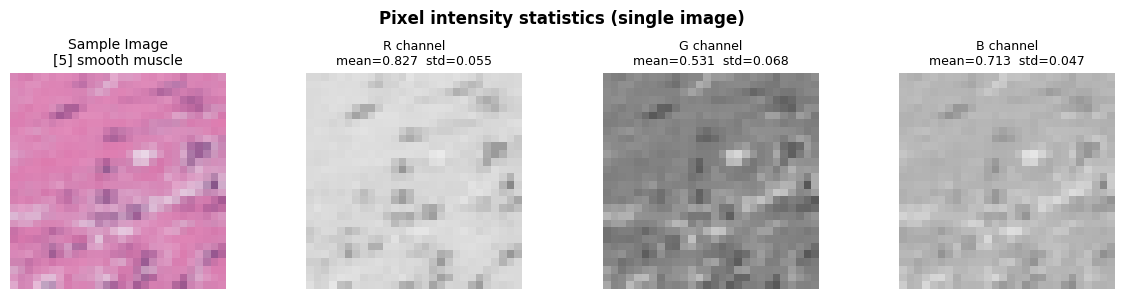

In [ ]:
# Pixel intensity statistics for one training image ─
sample_img, sample_label = train_raw[3]
# tensor shape [3, 28, 28], values in range [0,1]

print(f"Chosen image label: {int(sample_label)} — {CLASSES[int(sample_label)]}")
print(f"Tensor shape: {sample_img.shape}")
print()

channel_names = ['R', 'G', 'B']
means, stds = [], []
for c, name in enumerate(channel_names):
    ch = sample_img[c]
    m = ch.mean().item()
    s = ch.std().item()
    means.append(m)
    stds.append(s)
    print(f"  Channel {name}:  mean = {m:.6f}   std = {s:.6f}")
# sample img extract 1 channel at a time
# 3 channels
# measure the mean and std for each channel and save in list
# item convert the result to a python float to print it
print()
print("ImageNet normalisation statistics (reference):")
# Check the imagenet dataset and mean and std for each channel
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
for c, name in enumerate(channel_names):
    diff_m = abs(means[c] - imagenet_mean[c])
    diff_s = abs(stds[c] - imagenet_std[c])
    print(f"  Channel {name}:  ImageNet mean={imagenet_mean[c]:.3f}  (diff {diff_m:.3f})  "
          f"ImageNet std={imagenet_std[c]:.3f}  (diff {diff_s:.3f})")

# Visualise the chosen images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img.permute(1,2,0).numpy())
axes[0].set_title(f"Sample Image\n[{int(sample_label)}] {CLASSES[int(sample_label)]}", fontsize=10)
axes[0].axis('off')
for c, (name, color) in enumerate(zip(channel_names, ['red','green','blue'])):
    axes[c+1].imshow(sample_img[c].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[c+1].set_title(f"{name} channel\nmean={means[c]:.3f}  std={stds[c]:.3f}", fontsize=9)
    axes[c+1].axis('off')
plt.suptitle("Pixel intensity statistics (single image)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Q1.2 Pixel Statistics vs ImageNet

As can be seen with the precedent result, histopathology images (HE staining) differ from natural photographs:

**Mean values** are higher (closer to 1.0) because large portions of the slide are bright pink (eosin staining, extracellular matrix and cell cytoplasm) or near-white (unstained areas), pushing overall brightness up.

**Standard deviations** in histology images are typically lower than ImageNet ones because tissue patches have narrower chromatic range (predominantly pink/purple palette, because the staining is in this palette range). There is some deeper contrasts with the hematoxylin staining, but as it stains only nuclei, there is less contrast than in an usual picture

**Practical implication:** In the the part 4, we should still apply ImageNet normalisation (subtract ImageNet mean, divide by ImageNet std) because the pretrained feature detectors were calibrated for that distribution.  However, the mismatch between PathMNIST statistics and ImageNet ones may slightly impairs feature reuse, especially in the first conv layer


In [ ]:
# Dataset-wide statistics (for normalisation)
# Compute mean and std across all training images
loader_stats = DataLoader(train_raw, batch_size=512, shuffle=False, num_workers=2)
# too complicated to load all the images into memory
# process in batches of 512
# don't care about shuffle
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
n_pixels = 0
# three counters for each channel : sum of pixel values, sum of squared pixel values, total number of pixels

for imgs, _ in loader_stats:
    # imgs: [512, 3, 28, 28]
    channel_sum    += imgs.sum(dim=[0, 2, 3])
    # Keep channel dimensions and sum over batch, height, width
    channel_sq_sum += (imgs ** 2).sum(dim=[0, 2, 3])
    # same but for squared pixel values
    n_pixels       += imgs.shape[0] * 28 * 28
    # count the number of pixels in the batch and add to total

dataset_mean = channel_sum / n_pixels
dataset_std  = ((channel_sq_sum / n_pixels) - dataset_mean**2).sqrt()

print("PathMNIST training-set statistics:")
for c, name in enumerate(channel_names):
    print(f"  Channel {name}:  mean = {dataset_mean[c]:.4f}   std = {dataset_std[c]:.4f}")
print()
print("We will use these values for normalising inputs to the MLP and CNN.")
print("For ResNet-18 we use ImageNet statistics instead.")


PathMNIST training-set statistics:
  Channel R:  mean = 0.7405   std = 0.1237
  Channel G:  mean = 0.5330   std = 0.1768
  Channel B:  mean = 0.7058   std = 0.1244

We will use these values for normalising inputs to the MLP and CNN.
For ResNet-18 we use ImageNet statistics instead.


In [ ]:
# Temps total du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")
